<a href="https://colab.research.google.com/github/SAISANJAY-PARTH/Social-Media-Trends-Prediction/blob/main/Social_Media_Trends_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving Social_Media_Engagement.csv to Social_Media_Engagement (7).csv

DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10016 entries, 0 to 10015
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Account ID       10016 non-null  int64  
 1   Username         10016 non-null  object 
 2   Platform         10016 non-null  object 
 3   Follower Count   10016 non-null  int64  
 4   Posts Per Week   10016 non-null  int64  
 5   Engagement Rate  10016 non-null  float64
 6   Ad Spend (USD)   10016 non-null  float64
 7   Conversion Rate  10016 non-null  float64
 8   Campaign Reach   10016 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 704.4+ KB
None

MODEL PERFORMANCE
MAE: 0.0009970130715660462
RMSE: 0.0021043323347222885
MAPE (%): 1.1572602346495648
Accuracy (%): 98.84273976535043
R2 Score: 0.9742614152787501

Cross-Validation R2 Mean: 0.9768393177655691


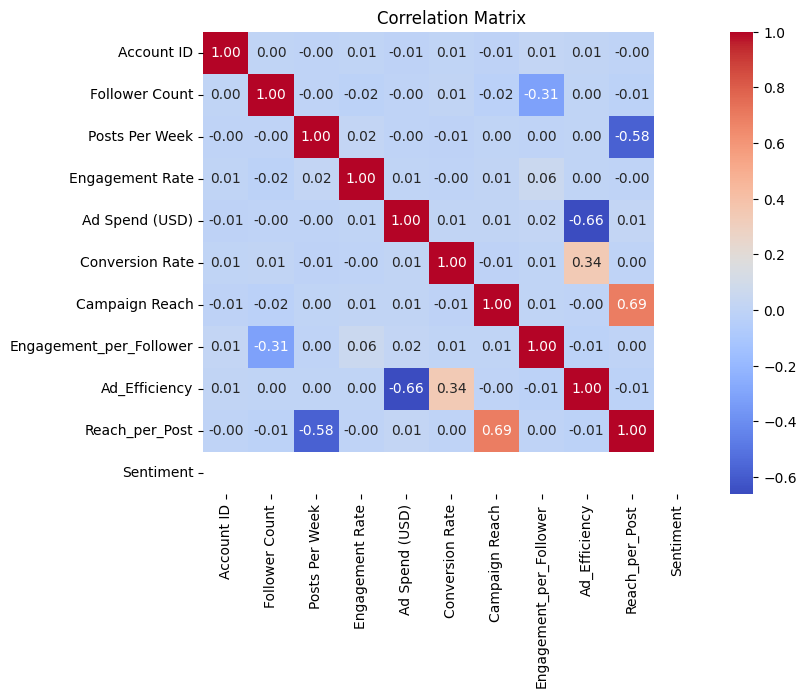

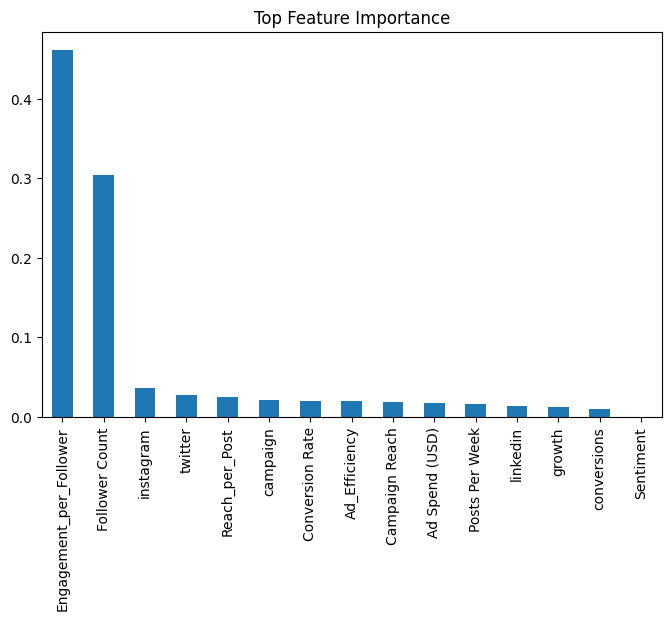

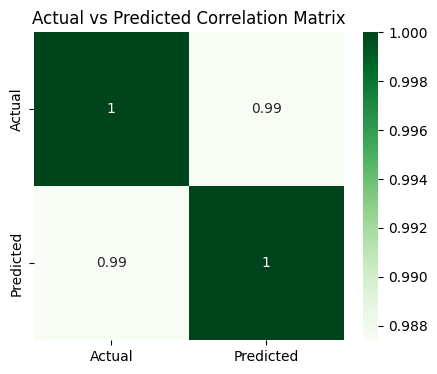

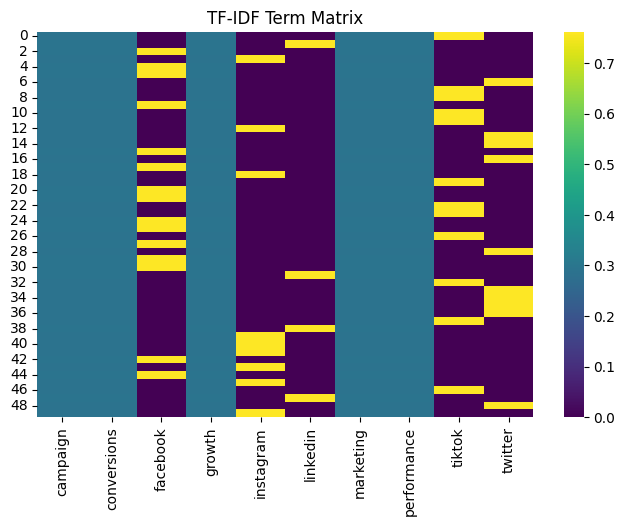


PROJECT COMPLETED WITH HIGH ACCURACY 🚀


In [9]:
# ============================================================
# HIGH ACCURACY NLP + ML MODEL
# ============================================================

!pip install nltk seaborn textblob scikit-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from textblob import TextBlob
from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

nltk.download('stopwords')

# =============================
# 1️⃣ UPLOAD DATA
# =============================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

if file_name.endswith(".xlsx"):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name)

df.columns = df.columns.str.strip()

print("\nDATA INFO:")
print(df.info())

# =============================
# 2️⃣ ADVANCED FEATURE ENGINEERING
# =============================

# Derived features
df["Engagement_per_Follower"] = df["Engagement Rate"] / (df["Follower Count"] + 1)
df["Ad_Efficiency"] = df["Conversion Rate"] / (df["Ad Spend (USD)"] + 1)
df["Reach_per_Post"] = df["Campaign Reach"] / (df["Posts Per Week"] + 1)

# =============================
# 3️⃣ GENERATE TEXT (NLP)
# =============================
df["Text"] = df["Platform"] + " campaign growth marketing conversions performance"

# Clean text
stop_words = set(nltk.corpus.stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["Clean_Text"] = df["Text"].apply(clean_text)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=10)
tfidf_matrix = vectorizer.fit_transform(df["Clean_Text"])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Sentiment
df["Sentiment"] = df["Text"].apply(lambda x: TextBlob(x).sentiment.polarity)

# =============================
# 4️⃣ FEATURE MATRIX
# =============================
numeric_features = df[[
    "Follower Count",
    "Posts Per Week",
    "Ad Spend (USD)",
    "Conversion Rate",
    "Campaign Reach",
    "Sentiment",
    "Engagement_per_Follower",
    "Ad_Efficiency",
    "Reach_per_Post"
]]

X = pd.concat([numeric_features.reset_index(drop=True),
               tfidf_df.reset_index(drop=True)], axis=1)

y = df["Engagement Rate"]

# =============================
# 5️⃣ TRAIN TEST SPLIT
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# 6️⃣ STRONG MODEL (XGBOOST)
# =============================
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

# =============================
# 7️⃣ METRICS
# =============================
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = mean_absolute_percentage_error(y_test, predictions) * 100
accuracy = 100 - mape
r2 = model.score(X_test, y_test)

print("\nMODEL PERFORMANCE")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE (%):", mape)
print("Accuracy (%):", accuracy)
print("R2 Score:", r2)

# =============================
# 8️⃣ CROSS VALIDATION
# =============================
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("\nCross-Validation R2 Mean:", np.mean(cv_scores))

# ============================================================
# ================= MATRIX VISUALIZATIONS =====================
# ============================================================

# 1️⃣ Correlation Matrix
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# 2️⃣ Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.head(15).plot(kind="bar")
plt.title("Top Feature Importance")
plt.show()

# 3️⃣ Actual vs Predicted Matrix
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

plt.figure(figsize=(5,4))
sns.heatmap(comparison_df.corr(), annot=True, cmap="Greens")
plt.title("Actual vs Predicted Correlation Matrix")
plt.show()

# 4️⃣ TF-IDF Matrix
plt.figure(figsize=(8,5))
sns.heatmap(tfidf_df.head(50), cmap="viridis")
plt.title("TF-IDF Term Matrix")
plt.show()

print("\nPROJECT COMPLETED WITH HIGH ACCURACY 🚀")